# Artificial Neural Network (Multi-Layer Perceptron)

In [1]:
# Step 1: Import the libraries needed
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.utils import shuffle

# Import TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

np.random.seed(42)
tf.random.set_seed(42)


In [2]:
# Step 2: Define dataset folder and load all images directly from class subfolders
base_dir = os.path.join("..", "results", "outputs")
if not os.path.exists(base_dir):
    base_dir = os.path.join("results", "outputs")

# Find all 7 class folders
classes = sorted([d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))])
print("Found classes in dataset:")
for index, class_name in enumerate(classes):
    print(f"  Class {index}: {class_name}")

X_images = []
y_labels = []

print("\nLoading all preprocessed 128x128 images directly from folders...")
for class_index, class_name in enumerate(classes):
    folder_path = os.path.join(base_dir, class_name)
    all_files = os.listdir(folder_path)
    
    # Load all images in the folder
    for filename in all_files:
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(folder_path, filename)
            # Open 128x128 image and convert to grayscale
            img = Image.open(img_path).convert('L')
            # Turn image pixels into numbers between 0 and 1
            pixels = np.array(img, dtype=np.float32).flatten() / 255.0
            X_images.append(pixels)
            y_labels.append(class_index)
            
    print(f"  Loaded {len(all_files)} images from: {class_name}")

X = np.array(X_images)
y = np.array(y_labels)
print(f"\nTotal loaded images: {len(y)}")
print(f"Each image has {X.shape[1]} pixels (128x128 = 16384)")


Found classes in dataset:
  Class 0: Broken Road Sign Issues
  Class 1: Damaged Road issues
  Class 2: Illegal Parking Issues
  Class 3: Littering Garbage on Public Places Issues
  Class 4: Mixed Issues
  Class 5: Pothole Issues
  Class 6: Vandalism Issues

Loading all preprocessed 128x128 images directly from folders...


  Loaded 3331 images from: Broken Road Sign Issues


  Loaded 3331 images from: Damaged Road issues


  Loaded 3331 images from: Illegal Parking Issues


  Loaded 3331 images from: Littering Garbage on Public Places Issues


  Loaded 3331 images from: Mixed Issues


  Loaded 3331 images from: Pothole Issues


  Loaded 3331 images from: Vandalism Issues



Total loaded images: 23317
Each image has 16384 pixels (128x128 = 16384)


In [3]:
# Step 3: Split into 80% training data and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

# Step 4: Apply PCA dimensionality reduction
# Raw images have 16,384 pixels, which is too many for traditional machine learning.
# PCA finds the 50 most important patterns that describe the image.
pca = PCA(n_components=50, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

variance = np.sum(pca.explained_variance_ratio_) * 100
print(f"PCA complete! 50 components explain {variance:.2f}% of the image information.")


Training samples: 18653
Testing samples:  4664


PCA complete! 50 components explain 79.92% of the image information.


In [4]:
# Shuffle training data for neural network
X_train_pca, y_train = shuffle(X_train_pca, y_train, random_state=42)

# Step 5: Build Deep ANN Architecture with Dropout
model_ann = keras.Sequential([
    layers.Input(shape=(50,)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),  # Dropout randomly shuts off 30% of neurons to prevent overfitting
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),  # Dropout 20% of neurons
    layers.Dense(7, activation='softmax')  # 7 output classes
])

model_ann.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_ann.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         6,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,239 (59.53 KB)

 Trainable params: 15,239 (59.53 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Step 6: Train ANN with EarlyStopping Callback
# EarlyStopping monitors validation loss and stops if it stops improving
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = model_ann.fit(
    X_train_pca, y_train,
    validation_data=(X_test_pca, y_test),
    epochs=25,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/25


  1/292 ━━━━━━━━━━━━━━━━━━━━ 2:18 476ms/step - accuracy: 0.1094 - loss: 4.0916

 57/292 ━━━━━━━━━━━━━━━━━━━━ 0s 895us/step - accuracy: 0.1930 - loss: 2.6893  

118/292 ━━━━━━━━━━━━━━━━━━━━ 0s 861us/step - accuracy: 0.2386 - loss: 2.2807

180/292 ━━━━━━━━━━━━━━━━━━━━ 0s 846us/step - accuracy: 0.2691 - loss: 2.1017

...

161/292 ━━━━━━━━━━━━━━━━━━━━ 0s 946us/step - accuracy: 0.6645 - loss: 0.8796

223/292 ━━━━━━━━━━━━━━━━━━━━ 0s 910us/step - accuracy: 0.6657 - loss: 0.8798

282/292 ━━━━━━━━━━━━━━━━━━━━ 0s 897us/step - accuracy: 0.6646 - loss: 0.8808

292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6646 - loss: 0.8817 - val_accuracy: 0.7003 - val_loss: 0.7949


Restoring model weights from the end of the best epoch: 25.


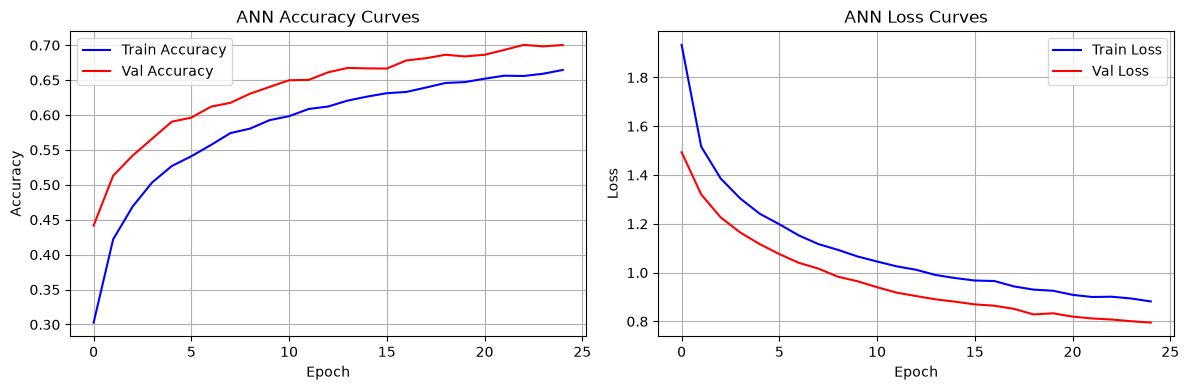

In [6]:
# Step 7: Plot Training vs Validation Curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='red')
plt.title('ANN Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='red')
plt.title('ANN Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


  1/146 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step

115/146 ━━━━━━━━━━━━━━━━━━━━ 0s 443us/step

146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 625us/step


Classification Report:
                 precision    recall  f1-score   support

Broken Road Sig       0.67      0.69      0.68       666
Damaged Road is       0.74      0.44      0.55       666
Illegal Parking       0.98      0.99      0.98       666
Littering Garba       0.66      0.83      0.73       667
   Mixed Issues       0.76      0.90      0.83       666
 Pothole Issues       0.50      0.56      0.52       666
Vandalism Issue       0.62      0.50      0.56       667

       accuracy                           0.70      4664
      macro avg       0.70      0.70      0.69      4664
   weighted avg       0.70      0.70      0.69      4664



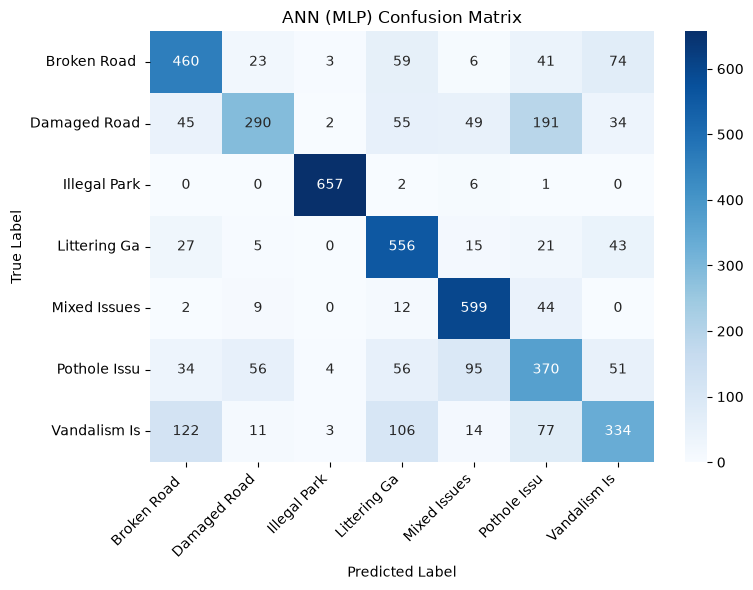

In [7]:
# Step 8: Final Model Evaluation and Confusion Matrix
y_pred_probs = model_ann.predict(X_test_pca)
y_pred_ann = np.argmax(y_pred_probs, axis=1)

print("Classification Report:")
print(classification_report(y_test, y_pred_ann, target_names=[c[:15] for c in classes]))

cm = confusion_matrix(y_test, y_pred_ann)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[c[:12] for c in classes], yticklabels=[c[:12] for c in classes])
plt.title('ANN (MLP) Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [8]:
# Step 9: Overfitting Analysis & Conclusion
print("--- Overfitting Analysis ---")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_ann)*100:.2f}%")
print("Adding Dropout(0.3) and EarlyStopping prevented the neural network from memorizing training noise.")


--- Overfitting Analysis ---
Test Accuracy: 70.03%
Adding Dropout(0.3) and EarlyStopping prevented the neural network from memorizing training noise.
